## Choropleth for reclaimed land

/var/folders/mq/h5hm4_jx7t7ckg3921cbcwgr0000gn/T/ipykernel_94144/2645200630.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


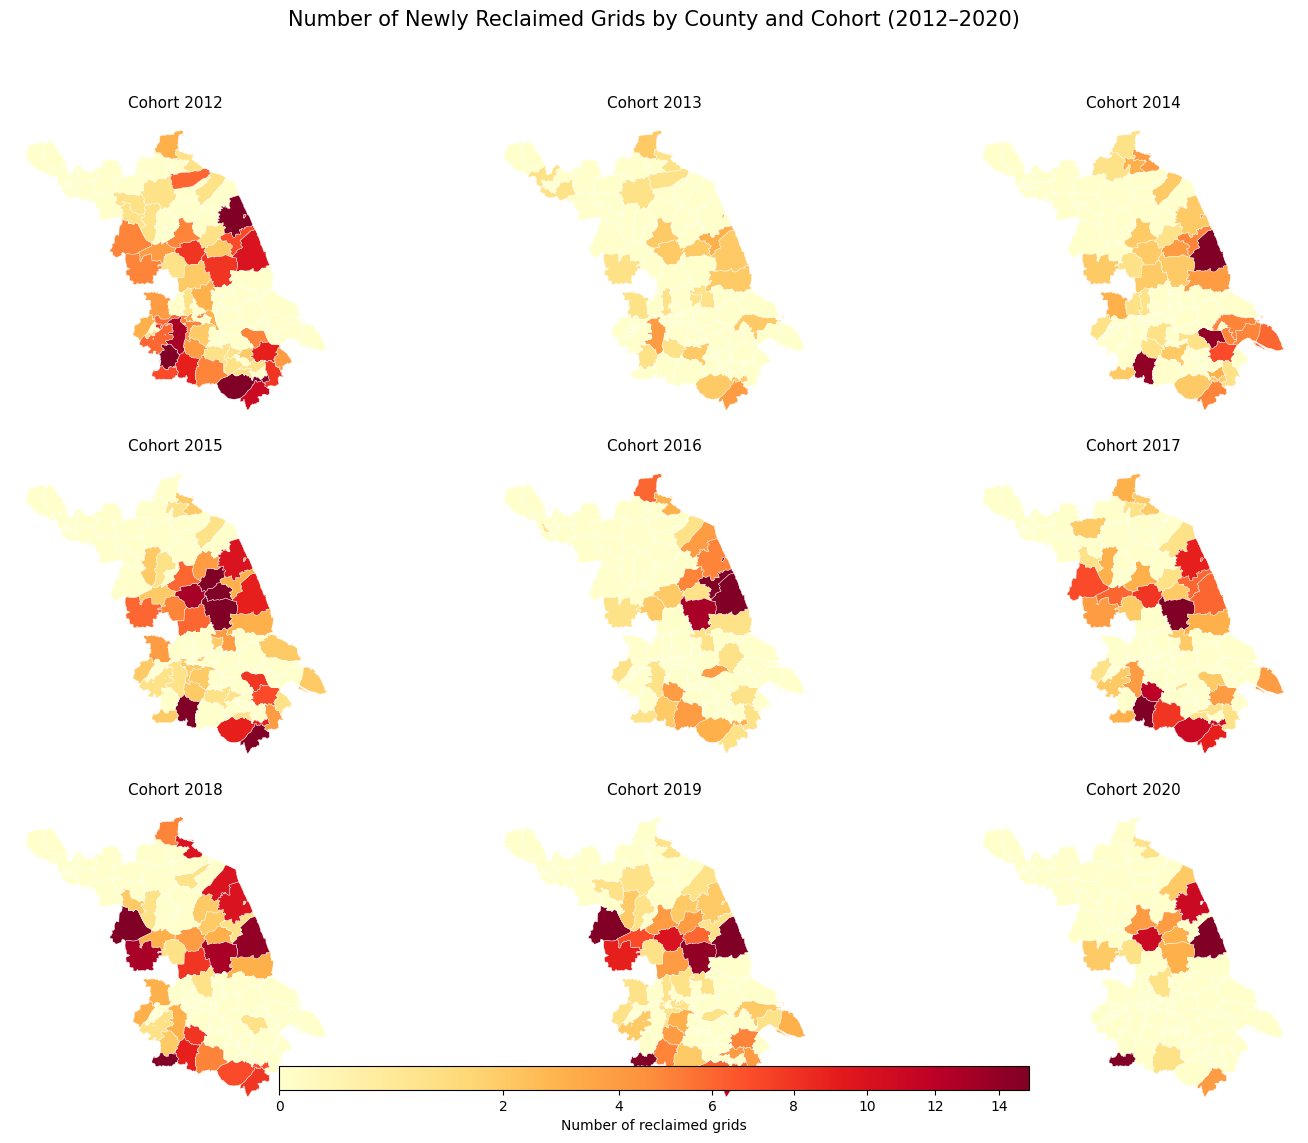

In [156]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === paths ===
china_path = "/Users/wangze/Dropbox/Emi/china.shp"
jiangsu_cohort_path = "/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_CGCS2000/jiangsu_cohort.csv"

# === load data ===
china = gpd.read_file(china_path)
jiangsu_cohort = pd.read_csv(jiangsu_cohort_path)

# Keep only Jiangsu province (Cd_Prvn = 32)
jiangsu_poly = china[china["Cd_Prvn"] == "32"].copy()

# Merge with jiangsu_cohort (ensure Cd_Cnty is same type)
jiangsu_poly["Cd_Cnty"] = jiangsu_poly["Cd_Cnty"].astype(str)
jiangsu_cohort["Cd_Cnty"] = jiangsu_cohort["Cd_Cnty"].astype(str)

merged = jiangsu_poly.merge(jiangsu_cohort, on="Cd_Cnty", how="left")

# Fill missing with 0 (counties without new land that year)
merged["n"] = merged["n"].fillna(0)

# === Plot ===
years = range(2012, 2021)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  # 9 years
axes = axes.flatten()

# Color normalization
vmax = merged["n"].quantile(0.98)  # clip extreme outliers
norm = mcolors.PowerNorm(gamma=0.6, vmin=0, vmax=vmax)

for i, year in enumerate(years):
    ax = axes[i]
    subset = merged[merged["cohort"] == year]
    subset.plot(
        column="n",
        cmap="YlOrRd",
        linewidth=0.3,
        edgecolor="white",
        legend=False,
        norm=norm,
        ax=ax,
        missing_kwds={
            "color": "lightgray",
            "edgecolor": "white",
            "label": "No data"
        }
    )
    ax.set_title(f"Cohort {year}", fontsize=11)
    ax.axis("off")

# Remove any extra empty subplot (e.g., if 9 slots but 9 years is exact, ignore)
if len(axes) > len(years):
    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])

# Shared colorbar
fig.suptitle("Number of Newly Reclaimed Grids by County and Cohort (2012–2020)", fontsize=15)
cax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
sm._A = []
fig.colorbar(sm, cax=cax, orientation="horizontal", label="Number of reclaimed grids")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


/var/folders/mq/h5hm4_jx7t7ckg3921cbcwgr0000gn/T/ipykernel_94144/1576785292.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


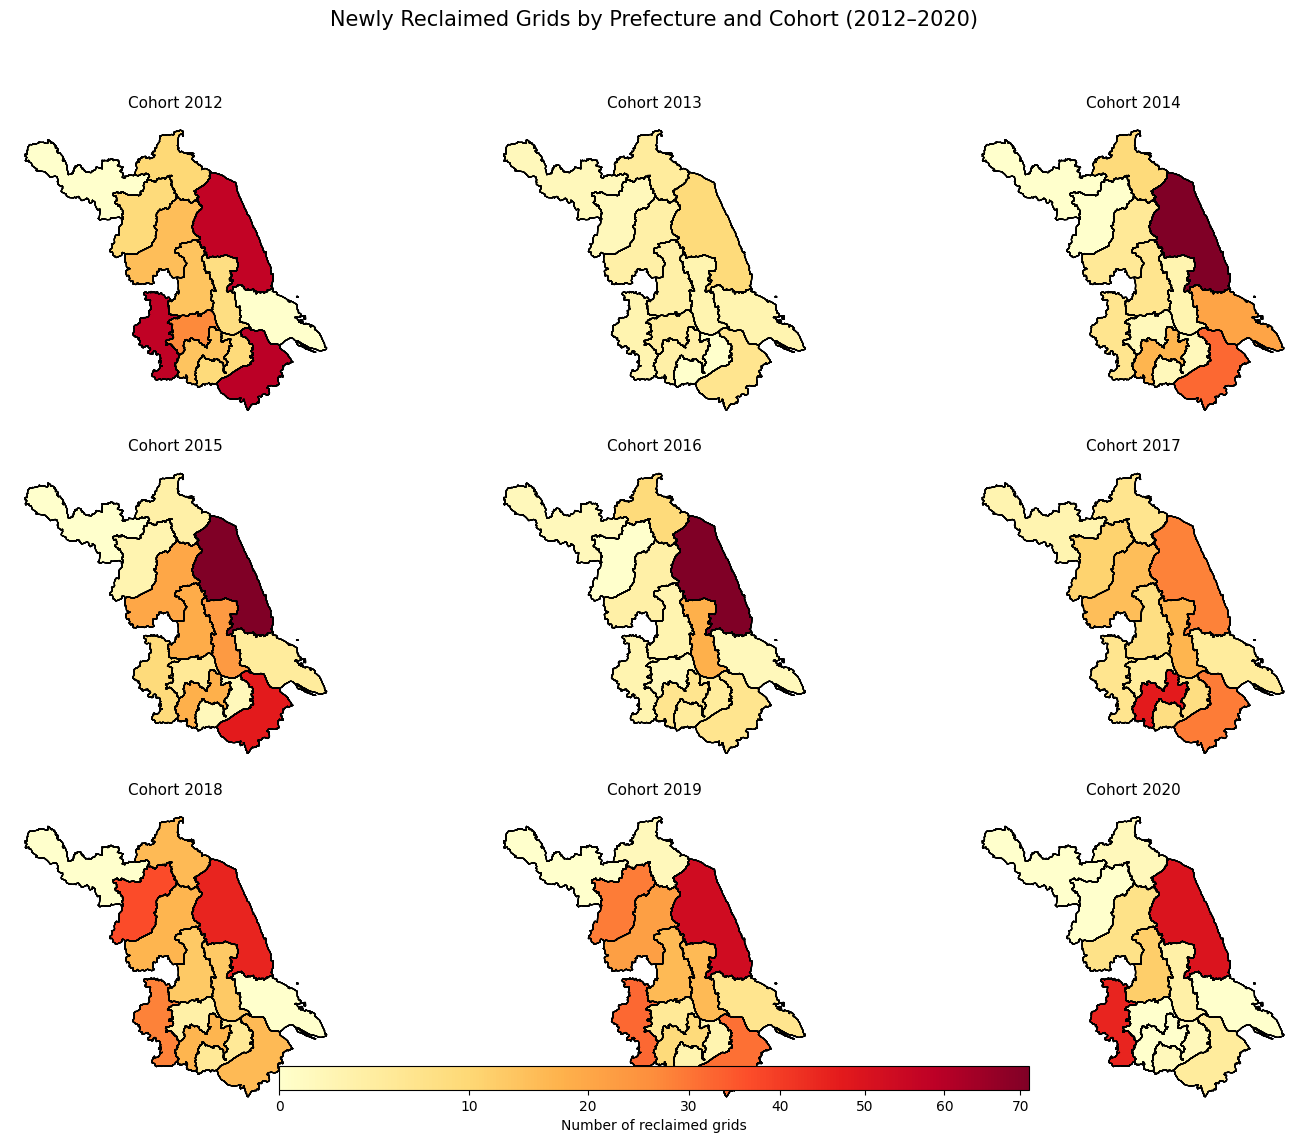

In [157]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === paths ===
china_path = "/Users/wangze/Dropbox/Emi/china.shp"
jiangsu_cohort_path = "/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_CGCS2000/jiangsu_cohort.csv"

# === load data ===
china = gpd.read_file(china_path)
jiangsu_cohort = pd.read_csv(jiangsu_cohort_path)

# === subset Jiangsu ===
jiangsu_poly = china[china["Cd_Prvn"] == "32"].copy()

# === ensure matching variable types ===
jiangsu_poly["Cd_Cnty"] = jiangsu_poly["Cd_Cnty"].astype(str)
jiangsu_poly["Cd_Prfc"] = jiangsu_poly["Cd_Prfc"].astype(str)
jiangsu_cohort["Cd_Cnty"] = jiangsu_cohort["Cd_Cnty"].astype(str)
jiangsu_cohort["Cd_Prfc"] = jiangsu_cohort["Cd_Prfc"].astype(str)

# === aggregate by prefecture ===
prfc_counts = (
    jiangsu_cohort.groupby(["Cd_Prfc", "Nm_Prfc", "cohort"], as_index=False)
    .agg(n_reclaimed=("n", "sum"))
)

# === merge to prefecture geometry ===
jiangsu_prfc_poly = (
    jiangsu_poly.dissolve(by=["Cd_Prfc", "Nm_Prfc"], as_index=False, aggfunc="first")
)
jiangsu_prfc_poly = jiangsu_prfc_poly.merge(prfc_counts, on="Cd_Prfc", how="left")
jiangsu_prfc_poly["n_reclaimed"] = jiangsu_prfc_poly["n_reclaimed"].fillna(0)

# === set up plotting ===
years = range(2012, 2021)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Color normalization
vmax = jiangsu_prfc_poly["n_reclaimed"].quantile(0.98)
norm = mcolors.PowerNorm(gamma=0.7, vmin=0, vmax=vmax)

# === plot ===
for i, year in enumerate(years):
    ax = axes[i]
    subset = jiangsu_prfc_poly[jiangsu_prfc_poly["cohort"] == year]
    if subset.empty:
        ax.axis("off")
        continue

    # 填色
    subset.plot(
        column="n_reclaimed",
        cmap="YlOrRd",
        linewidth=0.4,
        edgecolor="white",
        legend=False,
        norm=norm,
        ax=ax,
    )

    # 加粗地级市边界（黑色）
    jiangsu_prfc_poly.boundary.plot(ax=ax, color="black", linewidth=0.8)

    ax.set_title(f"Cohort {year}", fontsize=11)
    ax.axis("off")

# 删除多余子图
if len(axes) > len(years):
    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])

# === colorbar ===
fig.suptitle("Newly Reclaimed Grids by Prefecture and Cohort (2012–2020)", fontsize=15)
cax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
sm._A = []
fig.colorbar(sm, cax=cax, orientation="horizontal", label="Number of reclaimed grids")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


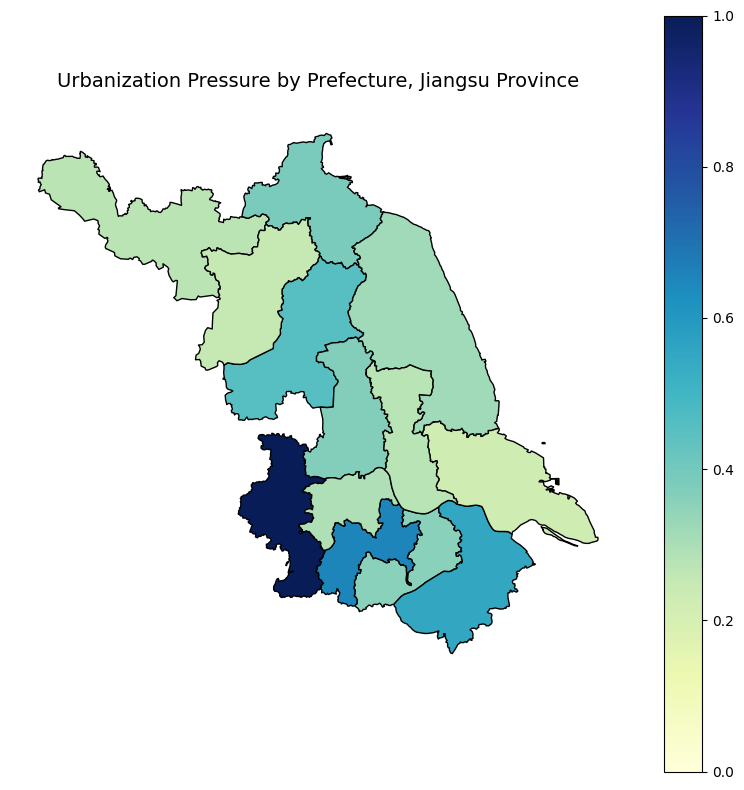

In [160]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === paths ===
china_path = "/Users/wangze/Dropbox/Emi/china.shp"
jiangsu_cohort_path = "/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_CGCS2000/jiangsu_cohort.csv"

# === load data ===
china = gpd.read_file(china_path)
jiangsu_cohort = pd.read_csv(jiangsu_cohort_path)

# === subset Jiangsu ===
jiangsu_poly = china[china["Cd_Prvn"] == "32"].copy()

# ensure variable type consistency
for col in ["Cd_Cnty", "Cd_Prfc"]:
    jiangsu_poly[col] = jiangsu_poly[col].astype(str)
    jiangsu_cohort[col] = jiangsu_cohort[col].astype(str)

# === prefecture-level average urban share ===
prfc_urban = (
    jiangsu_cohort.groupby(["Cd_Prfc"], as_index=False)
    .agg(urban_share=("urban_share", "mean"))
)

# dissolve county polygons to prefecture polygons
jiangsu_prfc_poly = jiangsu_poly.dissolve(by=["Cd_Prfc", "Nm_Prfc"], as_index=False, aggfunc="first")

# merge
jiangsu_prfc_poly = jiangsu_prfc_poly.merge(prfc_urban, on="Cd_Prfc", how="left")

# === plot ===
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# color scale
norm = mcolors.Normalize(vmin=0, vmax=1)

# main map
jiangsu_prfc_poly.plot(
    column="urban_share",
    cmap="YlGnBu",       # yellow-green-blue scale
    linewidth=1,
    edgecolor="black",
    legend=True,
    norm=norm,
    ax=ax
)



# finalize
ax.set_title("Urbanization Pressure by Prefecture, Jiangsu Province", fontsize=14, pad=15)
ax.axis("off")

plt.tight_layout()
plt.show()



/var/folders/mq/h5hm4_jx7t7ckg3921cbcwgr0000gn/T/ipykernel_94144/106071068.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


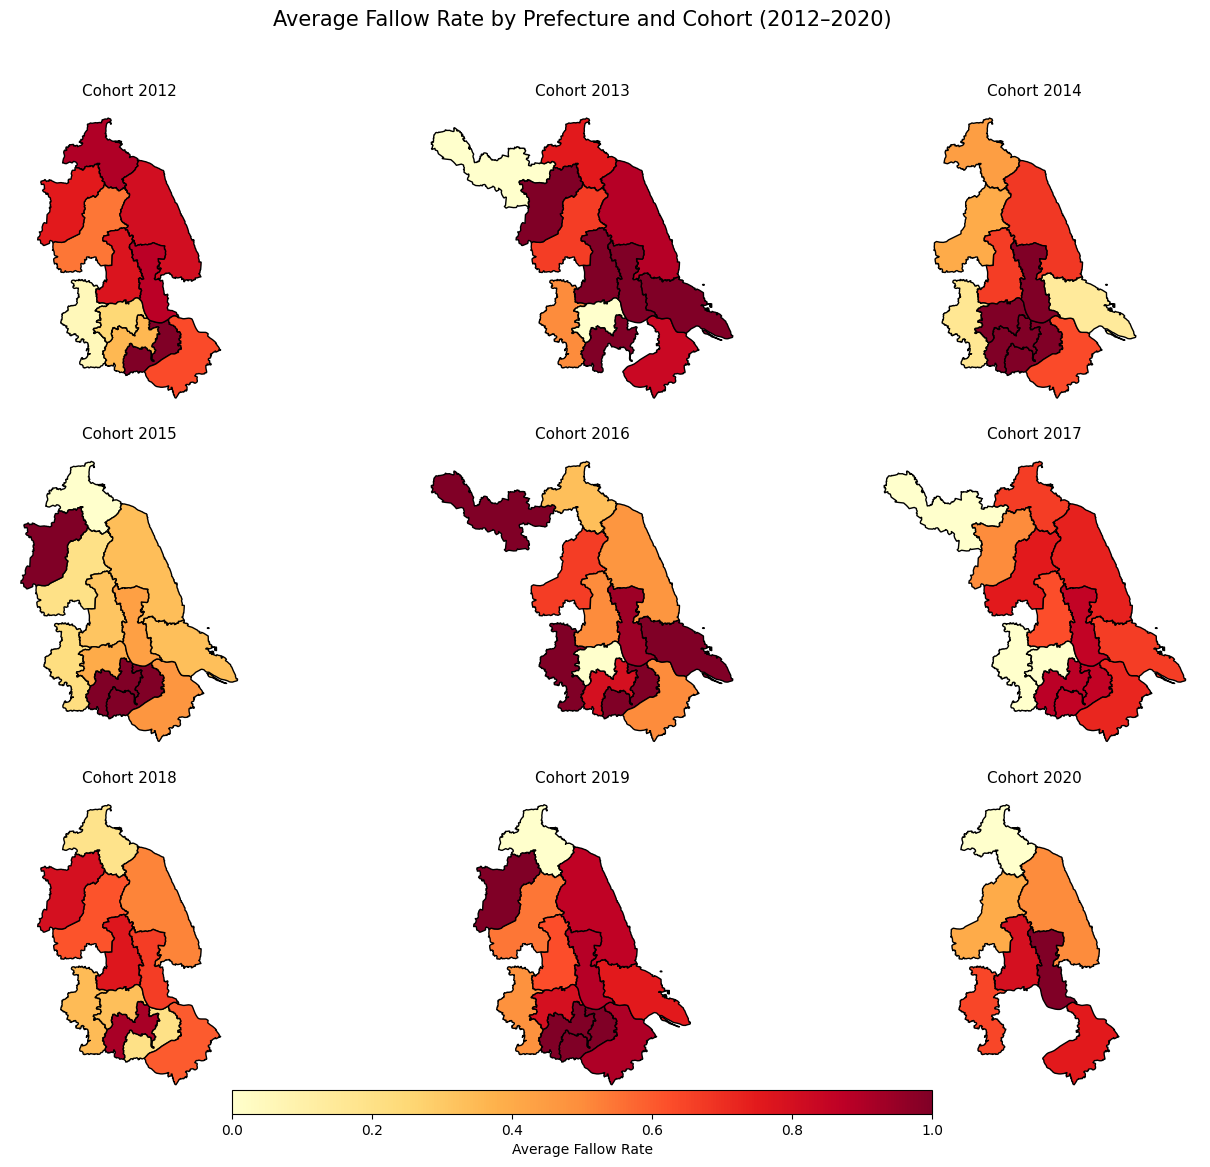

In [165]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# === 路径 ===
china_path = "/Users/wangze/Dropbox/Emi/china.shp"
jiangsu_path = "/Users/wangze/Dropbox/Emi/LandControl/geodata/Jiangsu_CGCS2000/jiangsu_cohort.csv"

# === 读取数据 ===
china = gpd.read_file(china_path)
jiangsu_cohort = pd.read_csv(jiangsu_path)

# === 仅保留有效年份 ===
jiangsu_cohort = jiangsu_cohort.query("2012 <= cohort <= 2020")

# === 计算每个地级市每年的平均撂荒率 ===
fallow_avg = (
    jiangsu_cohort
    .dropna(subset=["fallow_rate"])
    .groupby(["Cd_Prfc", "Nm_Prfc", "cohort"], as_index=False)
    .agg(fallow_rate_mean=("fallow_rate", "mean"))
)

# === 只保留江苏省 polygon ===
jiangsu_poly = china[china["Cd_Prvn"] == "32"].copy()

# dissolve 县为市（统一地级市轮廓）
jiangsu_prfc_poly = jiangsu_poly.dissolve(by=["Cd_Prfc", "Nm_Prfc"], as_index=False, aggfunc="first")

# merge 撂荒率数据
# ensure Cd_Prfc type一致
jiangsu_prfc_poly["Cd_Prfc"] = jiangsu_prfc_poly["Cd_Prfc"].astype(str)
fallow_avg["Cd_Prfc"] = fallow_avg["Cd_Prfc"].astype(str)

# merge 撂荒率数据
jiangsu_prfc_poly = jiangsu_prfc_poly.merge(fallow_avg, on="Cd_Prfc", how="left")


# === 颜色刻度设置 ===
vmin, vmax = 0, jiangsu_prfc_poly["fallow_rate_mean"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# === 绘图 ===
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, year in enumerate(range(2012, 2021)):
    ax = axes[i]
    subset = jiangsu_prfc_poly[jiangsu_prfc_poly["cohort"] == year]
    if subset.empty:
        ax.axis("off")
        continue
    
    subset.plot(
        column="fallow_rate_mean",
        cmap="YlOrRd",         # 黄色-红色渐变
        linewidth=1,
        edgecolor="black",
        legend=False,
        norm=norm,
        ax=ax
    )
    
    ax.set_title(f"Cohort {year}", fontsize=11)
    ax.axis("off")

# 统一颜色条
cax = fig.add_axes([0.25, 0.05, 0.5, 0.02])
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
sm._A = []
fig.colorbar(sm, cax=cax, orientation="horizontal", label="Average Fallow Rate")

fig.suptitle("Average Fallow Rate by Prefecture and Cohort (2012–2020)", fontsize=15, y=0.97)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
